In [93]:
import numpy as np
import matplotlib.pyplot as plt

In [94]:
P_infty = 101325 # Pa
rho_air = 1.225 #kg * m**(-3)

omega = 1 # s**(-1)

R = 25

# Pressure function
def P(r):
    if r < R:
        return 1/2 * rho_air * omega**2 * r**2 + P_infty - rho_air * omega**2 * R**2
    else:
        return -rho_air * (omega**2 * R**4) / (2 * r**2) + P_infty

# Velocity field (returns cylindrical/polar coordinates)
def u_polar(r):
    if r < 0:
        return np.array([0, omega*r])
    else:
        return np.array([0, omega * R**2 / r])



In [95]:
# Pressure function (vectorized)
def P(r):
    # Placeholders
    r = np.asarray(r)
    p = np.empty_like(r, dtype=float)
    
    # Points with r < R
    mask = r < R
    p[mask] = 1/2 * rho_air * omega**2 * r[mask]**2 + P_infty - rho_air * omega**2 * R**2
    # Points with r >= R
    mask_out = np.logical_not(mask)
    p[mask_out] = -rho_air * (omega**2 * R**4) / (2 * r[mask_out]**2) + P_infty
    return p

# Velocity field in polar coords (vectorized)
def u_polar(r):
    # Placehoolders
    r = np.asarray(r)
    u_r = np.zeros_like(r, dtype=float)
    u_theta = np.zeros_like(r, dtype=float)

    # Points with r < R
    mask_inner = r < R
    u_theta[mask_inner] = omega * r[mask_inner]

    # Points with r >= R
    m_outer = (np.logical_not(mask_inner))
    u_theta[m_outer] = omega * R**2 / r[m_outer]

    # Returns two numpy arrays
    return u_r, u_theta

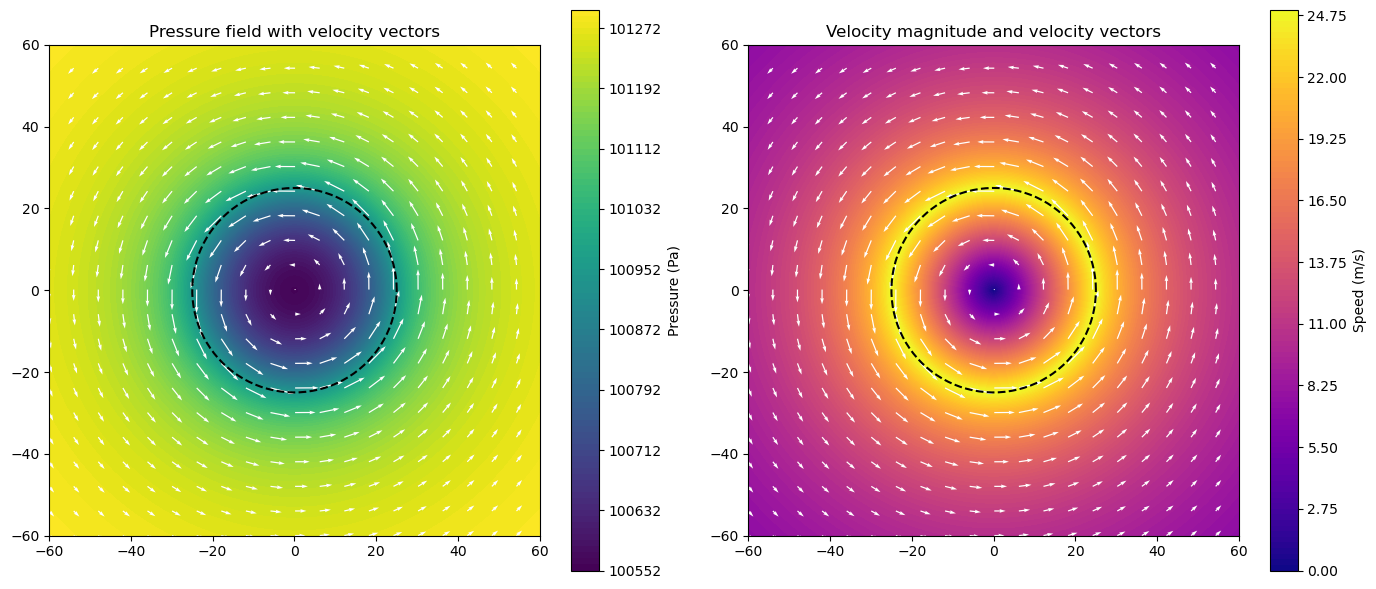

In [96]:
# Initialize grid
nx = 400
x = np.linspace(-60, 60, nx)
y = np.linspace(-60, 60, nx)
X, Y = np.meshgrid(x, y)

# Find corresponding values of r and theta
r = np.sqrt(X**2 + Y**2)
theta = np.arctan2(Y, X)

# Circle for r = R
theta_c = np.linspace(0, 2*np.pi, 100)
circle_x = R * np.cos(theta_c)
circle_y = R * np.sin(theta_c)

# Compute fields
P_field = P(r)
u_r_field, u_theta_field = u_polar(r)

# Convert polar to Cartesian
U = u_r_field * np.cos(theta) - u_theta_field * np.sin(theta)
V = u_r_field * np.sin(theta) + u_theta_field * np.cos(theta)
velocity_magnitude = np.sqrt(U**2 + V**2)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
# Pressure gradient plot
cf = ax.contourf(X, Y, P_field, levels=100, cmap='viridis')
# Velocity field vectors
ax.quiver(X[::20, ::20], Y[::20, ::20], U[::20, ::20], V[::20, ::20],
          color='white', scale=500, width=0.0025)
# Ring at r = R
ax.plot(circle_x, circle_y, color='k', linestyle='--', linewidth=1.5)

ax.set_title('Pressure field with velocity vectors')
ax.set_aspect('equal')
fig.colorbar(cf, ax=ax, label='Pressure (Pa)')



ax = axes[1]
# Velocity magnitude plot
cf2 = ax.contourf(X, Y, velocity_magnitude, levels=100, cmap='plasma')
# Velocity field vectors
ax.quiver(X[::20, ::20], Y[::20, ::20], U[::20, ::20], V[::20, ::20],
          color='white', scale=500, width=0.0025)
# Ring at r = R
ax.plot(circle_x, circle_y, color='k', linestyle='--', linewidth=1.5)


ax.set_title('Velocity magnitude and velocity vectors')
ax.set_aspect('equal')
fig.colorbar(cf2, ax=ax, label='Speed (m/s)')

plt.tight_layout()
plt.show()